<center> 

# DSSI: Summer 2024
    
## Classification: Part II

#### Authored by: Susanna Lange, PhD


<center>
<img src="https://raw.githubusercontent.com/amandakube/Data118LectureImages/main/UChicago_DSI.png" alt="UC-DSI" width="300" height="100">
</center>



In [ ]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

### Goal of this notebook

More Classification!

 - Logistic Regression

 - Focus on ideas surrounding
     - Intuition
     - Measures of Determining a 'Good' model: AUC

### knn


- predicts a class



Making 0/1 predictions is great, but what about probability as output?

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/model_example.png" alt="model_example" width="500">


## Logistic Regression

Logistic regression predicts the mean of the binary variable (a.k.a., a probability)! This can be used to predict a class!


Answer classification questions like:

Will a person develop a certain disease or not, based on specific health characteristics?

Is a piece of email spam or not, based on different features of the email?

Will a person default on a loan or not, based on their financial history?


(Just as in kNN)

Goal of a logistic regression


We want to model:
    
$$ Pr(outcome = 1| input)$$

![Screenshot%202024-06-05%20at%204.33.34%E2%80%AFPM.png](attachment:Screenshot%202024-06-05%20at%204.33.34%E2%80%AFPM.png)

This function is called the logistic function!

$$logistic(x) = \sigma(x) = \frac{1}{1+e^{-x}}$$

This can take different inputs depending on the features we have!





$$\sigma(\beta_0 +\beta_1x) = \frac{1}{1+e^{-\beta_0 -\beta_1x}}$$

### Intuition behind logistic regression

View dog/cat example in terms of logistic regression

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/model_example.png" alt="model_example" width="500">


In [ ]:
## This contains simulated data
# you can ignore this code
np.random.seed(seed=1243)
dog_ears = np.random.normal(loc=2.5, scale=2.25, size=20)

cat_ears = np.random.normal(loc=6, scale=1.5, size=20)
cat_claws = np.random.normal(loc=5, scale=2, size=20)

dog_claws = np.random.normal(loc=3.5, scale=1.56, size=20)
animal_labels = np.concatenate((np.full((20, ), [1]),  np.full((20, ), [0])))

characteristic_df = pd.DataFrame({'claw sharpness': np.concatenate((dog_claws, cat_claws)),
              'ear pointiness': np.concatenate((dog_ears, cat_ears)), 'Label': animal_labels})
characteristic_df = characteristic_df.sample(frac=1).reset_index(drop=True)
def standard_units(x):
    "Convert any array of numbers to standard units."
    return (x - np.average(x))/np.std(x,ddof=1)

characteristic_df['claw sharpness'] = standard_units(characteristic_df['claw sharpness'])
characteristic_df['ear pointiness'] = standard_units(characteristic_df['ear pointiness'])
characteristic_df.head()

,claw sharpness,ear pointiness,Label
0,-0.163080,0.991805,0
1,0.319878,-1.080775,1
2,1.125962,0.368576,0
3,-0.678487,-1.221375,1
4,0.930273,0.002494,0


In [ ]:
def logistic(t):
    return 1. / (1. + np.exp(-t))

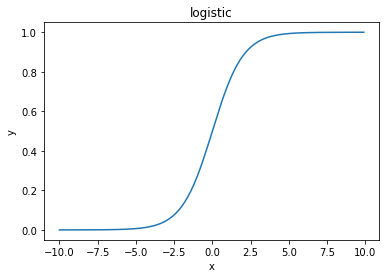

In [ ]:
x = np.arange(-10,10,0.1)

plt.plot(x, logistic(x))

plt.xlabel("x")
plt.ylabel("y")
plt.title("logistic")
plt.show()

Example:
    
Suppose we have a logistic model shown on the graph below

Predicts:  1: dog 0: cat
  
Input:
Claw sharpness

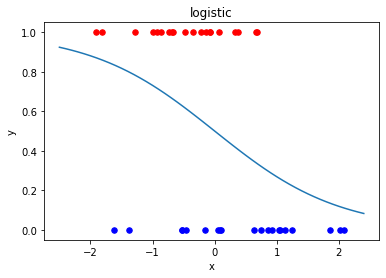

In [ ]:
x = np.arange(-2.5,2.5,0.1)


n = len(characteristic_df['claw sharpness'].loc[characteristic_df['Label']==0])
k = n-len(characteristic_df)
plt.scatter(characteristic_df['claw sharpness'].loc[characteristic_df['Label']==0],np.zeros(n), color='blue', s=30)
plt.scatter(characteristic_df['claw sharpness'].loc[characteristic_df['Label']==1],np.ones(n), color='red', s=30)

#different options for logisitic functions!
#plt.plot(x, logistic(-(14*x)))
#plt.plot(x, logistic(-(3*x)))
#plt.plot(x, logistic(-(2*x)))
plt.plot(x, logistic(-(x)))

#plt.plot(x, logistic(-(3*x)+1))

plt.xlabel("x")
plt.ylabel("y")
plt.title("logistic")
plt.show()

**Goal:** Find a logistic regression function that best fits the data.
    
Find the coefficients $$\sigma(\beta_0 +\beta_1x) = \frac{1}{1+e^{-\beta_0 -\beta_1x}}$$

Once we find the coefficients, we have a model.

**Question 1:** What does the output of a logistic regression model tell us?!

**Question 2:** How do we find the coefficients?

**Question 3:** How do we implement this in code.


#### What does the output of a logistic regression model tell us?!
    
    
The output is a probability!!!

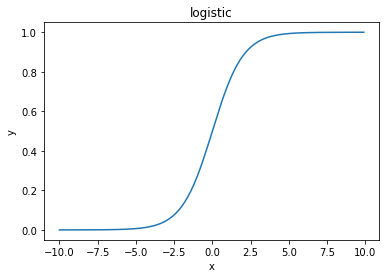

In [ ]:
x = np.arange(-10,10,0.1)
plt.plot(x, logistic(x))
plt.xlabel("x")
plt.ylabel("y")
plt.title("logistic")
plt.show()

We can specify a threshold, or decision boundary, that determines which binary output to classify our input.


- Default threshold is 0.5


 $$ Classification(x)=   \left\{
\begin{array}{ll}
      1 & P(y=1|x)>0.5 \\
      0 & otherwise\\
\end{array}
\right.  $$


Example:
    
Suppose we have a logistic model shown on the graph below

Predicts:  1: dog 0: cat
  
Input:
Claw sharpness

Suppose we find the model of $$\sigma(x) = \frac{1}{1+e^{-8x}}$$

fits our data.

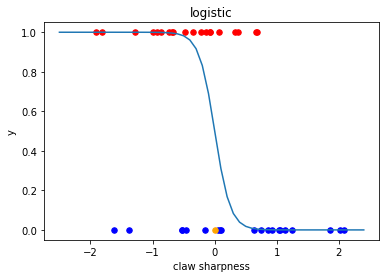

In [ ]:
#including different inputs
x = np.arange(-2.5,2.5,0.1)

y = logistic(-(8*x))


n = len(characteristic_df['claw sharpness'].loc[characteristic_df['Label']==0])
k = n-len(characteristic_df)
plt.scatter(characteristic_df['claw sharpness'].loc[characteristic_df['Label']==0],np.zeros(n), color='blue', s=30)
plt.scatter(characteristic_df['claw sharpness'].loc[characteristic_df['Label']==1],np.ones(n), color='red', s=30)

plt.scatter(0.01,0, color='orange', s=30)

plt.plot(x, y)


plt.xlabel("claw sharpness")
plt.ylabel("y")
plt.title("logistic")
plt.show()

Consider the orange dot above.

x = 0.01

Our model predicts this has a probability of 0.48 of being a dog.

In [ ]:
logistic(-(8*0.01))

0.48001065984441826

Since this threshold is 0.5 (default), then this would be classified as a cat.

If we changed the threshold, say to 0.4. This point would now be classified as a dog.

We have this extra control of deciding a threshold!

### How do we find the coefficients?

The process of finding a model (finding the logistic regression function) is an optimization problem.

We want to maximize the probability of the correct label p(y|x).

In practice, we define cross-entropy loss (How much $\hat{y}$ differs from the true y)

$$\mathcal{L}(\hat{y},y) = −\log p(y|x) = −[y\ log\hat{y}+(1−y)\log(1−\hat{y})]$$


Idea: We want the loss to be smaller if the model’s estimate is close to correct, and bigger if the model is confused.


Since $\hat{y}$ is our predicted output, it is a function of the input features ($x_1, x_2, ...x_n)$.

$$\hat{y} = \sigma(\beta_0 +\beta_1x_1+\beta_2x_2...\beta_nx_n) = \frac{1}{1+e^{-\beta_0 -\beta_1x-\beta_2x_2...\beta_nx_n}}$$

These coefficients are found through numerical methods of minimization.

Initialing the coefficients $\rightarrow$ calculating the loss $\rightarrow$ update the coefficients $\rightarrow$ iterate until convergence!

-6.624262886820521
-7.539958091181172
-8.178019324531098
-8.062228501838286
-8.108983720013038


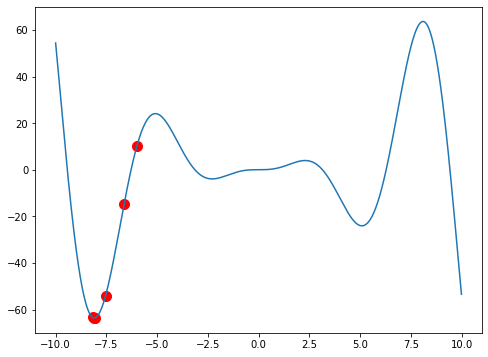

In [ ]:
## Ignore this code for now!

def f(x):
    return (x**2)*np.sin(x)

def df(x):
    return (2*x)*np.sin(x)+(x**2)*np.cos(x)
k=5
th0=-6    # try different starting points:  -6, -2, 0, 4
alpha=0.02  # choosing a good learning rate is important (try also 0.002, 0.2)

#start the plot
plt.figure(figsize=(8, 6))
x=np.arange(-10,10,0.01)
plt.plot(x,(x**2)*np.sin(x),linewidth=1.5)
plt.scatter(th0,f(th0),c="red",s=100)

for i in np.arange(k):
    th0=th0-alpha*df(th0)
    print(th0)
    plt.scatter(th0,f(th0),c="red",s=100)

###  How do we implement this in code?

In [ ]:
characteristic_df.head()

,claw sharpness,ear pointiness,Label
0,-0.163080,0.991805,0
1,0.319878,-1.080775,1
2,1.125962,0.368576,0
3,-0.678487,-1.221375,1
4,0.930273,0.002494,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = characteristic_df[['claw sharpness', 'ear pointiness']] #suppose this is the standarized data
y = characteristic_df.Label


#Testing and Training split
X_train, X_test, y_train, y_test \
    = train_test_split(X, y, test_size=0.2, random_state=6, shuffle = True)

[Documentation for Logistic Regression ](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [ ]:
logreg = LogisticRegression()

logreg.fit(X_train, y_train)

LogisticRegression()

In [ ]:
print(logreg.intercept_)
print(logreg.coef_)

[-0.3160187]
[[-0.50965902 -2.10300155]]


This model can be written as

$$\sigma(-0.316 -0.50965902(claw\_sharpness)-2.10300155(ear\_pointiness))$$


The sklearn model can output both the predicted class (the most likely) and the predicted probability

In [ ]:
small_test = pd.DataFrame({'claw': [0], 'ears': [0]})
logreg.predict_proba(small_test)

array([[0.57835367, 0.42164633]])

In [ ]:
#this works too
logreg.predict_proba(np.array([0,0]).reshape(-1,2))

/Users/susannalange/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.57835367, 0.42164633]])

In [ ]:
logreg.predict(small_test)

array([0])

## Model Evaluation

Measure of model performance

- Accuracy
- Sensitivity
- Specificity
- F1-score
- ROC Curves/AUC



#### Predict on the Test set

In [ ]:
predicted = logreg.predict(X_test)

predicted_probs = logreg.predict_proba(X_test)

In [1]:
from sklearn import metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test,predicted)

recall = recall_score(y_test,predicted)

precision = precision_score(y_test,predicted)

f1= f1_score(y_test,predicted)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)

NameError: name 'y_test' is not defined

## Thresholds and AUC

Anything greater than 0.5 is more likely than not to happen, so we predict that it will be a positive.

Anything less than 0.5 is more likely to not happen, so we predict that it will not happen.

We do not have to use 0.5 as a threshold! You could change it to be any value between 0 and 1.


The ROC (receiver operating characteristic) curve plots sensitivity (true positive rate) against 1 - specificity (true negative rate) at various thresholds.


AUC stands for Area Under the (ROC) Curve.

AUC always falls between 0 and 1, with values closer to 1 being more desirable.

## ROC Curve

<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/1/13/Roc_curve.svg/1920px-Roc_curve.svg.png' width=1000>


Image Credit: https://commons.wikimedia.org/wiki/File:Roc_curve.svg

[1.9307542  0.9307542  0.75848575 0.42525653 0.34398935 0.20979522
 0.08958844 0.05867863 0.03572199]
[0.   0.   0.   0.25 0.25 0.25 0.5  0.75 1.  ]
[0.   0.25 0.5  0.5  0.75 1.   1.   1.   1.  ]


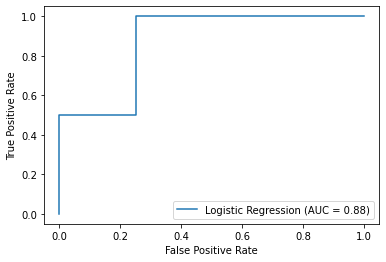

In [ ]:
my_fpr, my_tpr, thresholds = metrics.roc_curve(y_test, predicted_probs[:,1], drop_intermediate=False)
my_roc_auc = metrics.auc(my_fpr, my_tpr)

print(thresholds)
print(my_fpr)
print(my_tpr)
display = metrics.RocCurveDisplay(fpr=my_fpr, tpr=my_tpr, roc_auc=my_roc_auc, estimator_name='Logistic Regression')
display.plot();

In [ ]:
#Note: how the thresholds are chosen
#thresholds[0] represents no instances being predicted and is arbitrarily set to max(predicted_probs[:,1]) + 1.
predicted_probs[:,1]

array([0.42525653, 0.34398935, 0.03572199, 0.9307542 , 0.75848575,
       0.08958844, 0.20979522, 0.05867863])

A threshold of 0.425  has fpr of 0.25 and a tpr of 1.

This point is closest to the upper left corner of (0,1)

AUC is classification-threshold-invariant. It measures the quality of the model's predictions irrespective of what classification threshold is chosen

- measure of the method across all thresholds

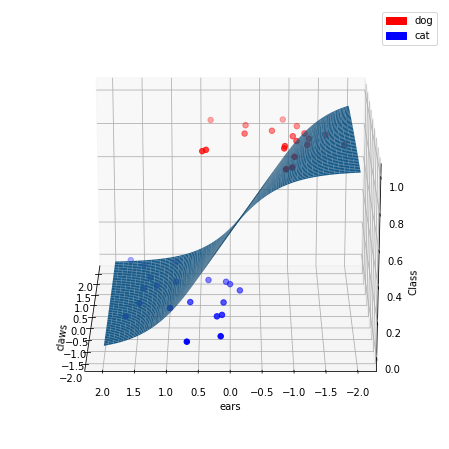

In [ ]:
#hide code
import matplotlib.patches as mpatches
fig = plt.figure(figsize = (12,8))
ax = plt.axes(projection='3d')

X = np.arange(-2,2,0.01)
Y = np.arange(-2,2,0.01)
X, Y = np.meshgrid(X, Y)
Z = logistic(-0.3160187-0.50965902*X-2.10300155*Y)

ax.plot_surface(X, Y, Z)

ax.scatter3D(characteristic_df['claw sharpness'].loc[characteristic_df['Label']==0],characteristic_df['ear pointiness'].loc[characteristic_df['Label']==0], np.zeros(n), color='blue', s=30)
ax.scatter3D(characteristic_df['claw sharpness'].loc[characteristic_df['Label']==1],characteristic_df['ear pointiness'].loc[characteristic_df['Label']==1],np.ones(n), color='red', s=30)

r_patch = mpatches.Patch(color='red', label='dog')
b_patch = mpatches.Patch(color='blue', label='cat')
ax.view_init(20, 180)

ax.legend(handles=[r_patch, b_patch])
ax.set_xlabel('claws')
ax.set_ylabel('ears')
ax.set_zlabel('Class');

#### <code style="background:Thistle;color:black"> Activity/Investigation Lab: Logisitic Regression</code>

Let's continue with our data from last time, except now we want to use Logistic Regression.
Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!



To help rescue crews and retrieve the lost passengers, you are challenged to predict which passengers were transported by the anomaly using records recovered from the spaceship’s damaged computer system.

Help save them and change history!


** This activity is taken from Kaggle:
Addison Howard, Ashley Chow, Ryan Holbrook. (2022). Spaceship Titanic. Kaggle. https://kaggle.com/competitions/spaceship-titanic

Please note the data has been cleaned slightly for use in this notebook.

Variable description:

PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.

HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.

CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.

Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.

Destination - The planet the passenger will be debarking to.

Age - The age of the passenger.

VIP - Whether the passenger has paid for special VIP service during the voyage.

RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.

Name - The first and last names of the passenger.

Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

Now we are going to use Logistic regression to predict the output! In particular, we will focus on 2 models.

The first few questions are the same as the kNN notebook. Feel free to copy over your code and discuss in your groups why each step is important.

Read in data!

In [ ]:
space_df = pd.read_csv('space_data.csv')

**Question 1**: We want to use the numerical variables: 'Age','RoomService','FoodCourt','ShoppingMall', 'Spa'. Our predicted output will be 'transported.

Create a collection of these features and store them in variable 'x'. Convert the transported column to 0/1 values: 1 = yes, 0 = no, and store that in variable 'y'.

In [ ]:
## code here

In [ ]:
#more space here

**Question 2:** Split the data into 3 parts: a training set, a validation set, and a test set.

In [ ]:
## code here

In [ ]:
#more space here

**Question 3:** We want to standardize the data. Ideally, we are treating the test data as 'unseen' data. If we use both the training and test set to standardize, the training data will be influenced by the distribution of the test data!! This is not good.

To prevent this, we standardize the training data and use the mean and std of the training data to standardize the test data! Since we have a holdout validation set, we can also use the mean and std of the training data to standardize the validation set.


Remember the .fit line below computes the mean and std of the given 'data'. We can then use the .transform to standardize the data or new data (ie. training or test data).

```python
scaler = StandardScaler()
scaler.fit(data)

scaler.transform(new_data)
```

In [ ]:
## code here

In [ ]:
#more space here

**Question 4:** Create 2 Logistic Regression models: model_1 uses the variables 'Age' and 'RoomService' and model_2 uses 'Age','RoomService','FoodCourt','ShoppingMall', 'Spa'.

In [ ]:
## code here

**Question 5:** Use AUC to compare the two models on the validation set. (note you will have to modify x_train so that is only takes the variables of interest.

In [ ]:
## code here


**Question 6:**  For your choice of model, evaulate on the test set.

In [ ]:
## code here


### What if we wanted to use a categorical variable in our model??

HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.

In [ ]:
space_df.HomePlanet.unique()

array(['Europa', 'Earth', 'Mars'], dtype=object)

Two common options:
    
**Dummy Variable Encoding** and **Label encoding**

Dummy Variable Encoding:

    
We may be interested in predicting a response based on a categorical predictor. E.g., Seasons, Holiday, Gender

 - To incorporate a categorical variable into a model, we might use an **indicator variable** (also called **dummy variable**)

 - Indicator variables are categorical variables that have been coded as 0 or 1. Using an indicator variable in place of a category name allows for these variables to be directly used in a machine learning model!


 - Example - gender: define G = 0 if male and G = 1 if female

How do we incorporate more than 2 categories?

Suppose we have exactly 3 categories (similar to above: 'Europa', 'Earth', 'Mars')

Should we encode this as 0,1,2? Discuss in your groups.



<details><summary><button>See here: </button></summary>
<p>
    
Encoding a nominal variable (a categorical variable with no ordering) as 0,1,2 enforces an order on it! This implies the 'distance' away from category 0 and 1 is the same distance as category 1 and 2. And what about categories 0 and 2? We would be implying categories 0 and 2 are less related than categories 0 and 1 (for example).
</p>
</details>


We can use dummy encoding on 3 variables too! Europa can be 0/1 and Earth can be 0/1. We actually don't need to (and don't want to) include a third category of Mars being 0/1 because that information is already encoded in the other two columns!

How is it encoded in the other columns? Talk to your group before looking at a justification below.

<details><summary><button>See here: </button></summary>
<p>
    
When Europa is 0 and Earth is 0 then it must be true that Mars is 1. And if one of Europa or Earth is 1 then Mars must be 0.

So dummy variable encoding creates k-1 new 0/1 columns in the dataframe that encode the variable information.</p>
</details>



#### New method

```python
pd.get_dummies(df, columns = ['col_name'], drop_first = True)
```

[documentation here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)

In [ ]:
#what does this do???
new_dataframe = pd.get_dummies(space_df, columns = ['HomePlanet'], dtype=float,drop_first=True)
new_dataframe.head()

,PassengerId,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,HomePlanet_Europa,HomePlanet_Mars
0,0001_01,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,1.0,0.0
1,0002_01,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0.0,0.0
2,0003_01,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,1.0,0.0
3,0003_02,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,1.0,0.0
4,0004_01,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0.0,0.0


Label encoding is another option to encode categorical features in your model.

Suppose we did have 3 categories: 1st class, 2nd class, 3rd class.

If we **can justify** that there is an ordering and that the difference between 2 categories is equal and uniform, then label encoding will allow us to encode categories as numbers: 0,1,2.

#### New method

```python
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()
  
df['col_name']= label_encoder.fit_transform(df['col_name])

```

[documentation here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)


In [ ]:
d = {'test score': ['low', 'med', 'high', 'med', 'low'], 'random 1': [3, 4, 2, 1, 6], 'random 2': [77,99,12,54,5]}
my_df = pd.DataFrame(data=d)
my_df

,test score,random 1,random 2
0,low,3,77
1,med,4,99
2,high,2,12
3,med,1,54
4,low,6,5


In [ ]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()
my_df['test score'] = label_encoder.fit_transform(my_df['test score'])
my_df

,test score,random 1,random 2
0,1,3,77
1,2,4,99
2,0,2,12
3,2,1,54
4,1,6,5


#### <code style="background:Thistle;color:black"> Activity (if Time)</code>

Choose one categorical variable from the space titanic data to include in your model and rerun your analysis.

In [ ]:
#code